In [ ]:
import re
import random
import collections
import contextlib
import io
import os
import subprocess

import numpy as np
import matplotlib.pyplot as plt
import rdflib
from rdflib import URIRef
from SPARQLWrapper import SPARQLWrapper, JSON
from transformers import pipeline
from rouge_score import rouge_scorer as rs
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score as bert_score_fn
from sklearn.metrics import cohen_kappa_score, confusion_matrix

RANDOM_SEED = 24


# Part 1: Input Parsing (NER + Intent)

Takes a raw user question and extracts two things: the astronomical objects being asked about, and the kind of information being requested. These feed directly into the KG query in Part 2.

## 1.a — Entity Extraction (NER)

We use `dslim/bert-base-NER`, a BERT model fine-tuned to find named entities in text.
It labels each word as a person (PER), organization (ORG), location (LOC), or misc (MISC).
Astronomy objects like stars and galaxies tend to come back as MISC or LOC.

In [2]:
# Downloads ~400MB on first run, cached locally after that
ner = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")
print("NER model loaded")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NER model loaded


In [3]:
# Verify NER picks up astronomy object names correctly
test_questions = [
    "What is the Sun made of?",
    "Where is the Andromeda Galaxy located?",
    "How hot is Betelgeuse?",
    "What planets orbit around the Sun?",
]

for q in test_questions:
    raw = ner(q)
    entities = [r['word'] for r in raw if r['score'] > 0.5]
    print(f"Q: {q}")
    print(f"   Entities found: {entities}")
    print()

Q: What is the Sun made of?
   Entities found: ['Sun']

Q: Where is the Andromeda Galaxy located?
   Entities found: ['Andromeda Galaxy']

Q: How hot is Betelgeuse?
   Entities found: ['Betelgeuse']

Q: What planets orbit around the Sun?
   Entities found: ['Sun']



## 1.b — Intent Classification

We use `facebook/bart-large-mnli`, a zero-shot classifier.
Zero-shot means we give it our own label names and it picks the best match
without any astronomy-specific training data.

Descriptive phrases work better than single words as labels — the model matches
against meaning, not exact wording. A confidence fallback ensures low-confidence
predictions default to `description` rather than guessing.

In [4]:
# Downloads ~1.5GB on first run, cached locally after that
intent_clf = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
print("Intent model loaded")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Intent model loaded


In [5]:
# Verbose labels perform better than single words for zero-shot classification
INTENT_MAP = {
    "chemical composition elements or what something is made of": "composition",
    "location or where something is found":                       "location",
    "temperature or how hot or cold something is":                "temperature",
    "size mass or how big something is":                          "size",
    "discovery or who found it or when it was discovered":        "discovery",
    "general description definition or overview of what it is":   "description",
    "orbital mechanics or what objects orbit around something":   "orbital",
}

INTENT_LABELS = list(INTENT_MAP.keys())

def parse_question(question, ner_model, clf_model):
    entities       = [r['word'] for r in ner_model(question) if r['score'] > 0.5]
    if not entities:                               # ← add this
        entities = kg_label_fallback(question, g)  # ← add this
    result         = clf_model(question, candidate_labels=INTENT_LABELS)
    verbose_intent = result['labels'][0]
    confidence     = result['scores'][0]
    intent         = INTENT_MAP[verbose_intent]
    if confidence < 0.50:
        intent = "description"
    return {"entities": entities, "intent": intent, "confidence": round(confidence, 2)}



for q in test_questions:
    print(parse_question(q, ner, intent_clf))

{'entities': ['Sun'], 'intent': 'description', 'confidence': 0.45}
{'entities': ['Andromeda Galaxy'], 'intent': 'location', 'confidence': 0.88}
{'entities': ['Betelgeuse'], 'intent': 'temperature', 'confidence': 0.54}
{'entities': ['Sun'], 'intent': 'orbital', 'confidence': 0.78}


## 1.c — Query Type and Filter Parsing

Some questions ask about a specific known object (lookup), others search for objects
matching criteria (filter). A rule-based detector separates these — if the question
names a category type (star, planet) and contains a constraint word, it's a filter query.
Filter questions are then parsed for search type, constraint predicates, and values.

In [6]:
# Maps plain English type words to DBpedia ontology classes
SEARCH_TYPE_MAP = {
    "star":           "dbo:Star",
    "stars":          "dbo:Star",
    "planet":         "dbo:Planet",
    "planets":        "dbo:Planet",
    "galaxy":         "dbo:Galaxy",
    "galaxies":       "dbo:Galaxy",
    "nebula":         "dbo:Nebula",
    "nebulae":        "dbo:Nebula",
    "nebulas":        "dbo:Nebula",
    "constellation":  "dbo:Constellation",
    "constellations": "dbo:Constellation",
}

CONSTRAINT_WORDS = [
    "contain", "contains", "have", "has", "with",
    "below", "above", "less than", "more than",
    "between", "in", "that are", "that have"
]

def detect_query_type(question):
    q_lower = question.lower()
    has_type_word  = any(word in q_lower.split() for word in SEARCH_TYPE_MAP)
    has_constraint = any(c in q_lower for c in CONSTRAINT_WORDS)
    if has_type_word and has_constraint:
        return "filter"
    return "lookup"


# Verify lookup vs filter classification
filter_tests = [
    "How hot is Mars?",
    "What stars contain hydrogen?",
    "What is the Andromeda Galaxy?",
    "What planets have a temperature below 300K?",
    "Who discovered Neptune?",
    "What galaxies are in the Local Group?",
]
for q in filter_tests:
    print(f"{detect_query_type(q):8}  {q}")

lookup    How hot is Mars?
filter    What stars contain hydrogen?
lookup    What is the Andromeda Galaxy?
filter    What planets have a temperature below 300K?
lookup    Who discovered Neptune?
filter    What galaxies are in the Local Group?


In [7]:
CONSTRAINT_KEYWORD_MAP = {
    "composition":  ["contain", "contains", "made of", "consist", "composed"],
    "temperature":  ["temperature", "hot", "cold", "warm", "cool", "kelvin"],
    "location":     ["in", "located", "location", "within", "inside"],
    "size":         ["big", "large", "small", "mass", "radius", "size", "diameter"],
    "discovery":    ["discovered", "found", "discoverer"],
    "orbital":      ["orbit", "orbits", "orbiting", "period"],
}

COMPARISON_MAP = {
    "below":     "<",  "less than":  "<",  "under":        "<",  "colder than": "<",
    "above":     ">",  "more than":  ">",  "over":         ">",  "hotter than": ">",
    "equal to":  "=",  "exactly":    "=",
}

def parse_filter_question(question, ner_model):
    q_lower = question.lower()
    words   = q_lower.split()

    # Find search type
    search_type = None
    for word in words:
        if word in SEARCH_TYPE_MAP:
            search_type = SEARCH_TYPE_MAP[word]
            break

    # Split on "and" — keep original case for NER, lowercase for keyword matching
    clauses_lower    = [c.strip() for c in q_lower.split(" and ")]
    clauses_original = [c.strip() for c in question.split(" and ")]

    constraints = []
    for clause, clause_orig in zip(clauses_lower, clauses_original):
        constraint_intent = None
        for intent, keywords in CONSTRAINT_KEYWORD_MAP.items():
            if any(kw in clause for kw in keywords):
                constraint_intent = intent
                break
        if not constraint_intent:
            continue

        comparison = ">"   # default: existence check
        for phrase, op in COMPARISON_MAP.items():
            if phrase in clause:
                comparison = op
                break

        # NER on original-case clause; fallback to regex; fallback to numbers
        entities = [r["word"] for r in ner_model(clause_orig) if r["score"] > 0.5]
        values   = [e for e in entities if e.lower() not in SEARCH_TYPE_MAP]

        if not values:
            for pattern in [r"contain(?:s)?\s+(\w+)", r"made\s+of\s+(\w+)",
                            r"composed\s+of\s+(\w+)", r"consist(?:s)?\s+of\s+(\w+)"]:
                match = re.search(pattern, clause)
                if match:
                    values = [match.group(1).capitalize()]
                    break

        if not values:
            numbers = re.findall(r'\d+\.?\d*', clause)
            values  = numbers if numbers else ["0"]

        constraints.append({"intent": constraint_intent, "comparison": comparison, "values": values})

    return {"search_type": search_type, "constraints": constraints}


# Test single and multi-constraint parsing
print(parse_filter_question("What planets have a temperature below 300 and have moons?", ner))
print(parse_filter_question("What stars contain hydrogen?", ner))
print(parse_filter_question("What galaxies are in the Local Group?", ner))

{'search_type': 'dbo:Planet', 'constraints': [{'intent': 'temperature', 'comparison': '<', 'values': ['300']}]}
{'search_type': 'dbo:Star', 'constraints': [{'intent': 'composition', 'comparison': '>', 'values': ['Hydrogen']}]}
{'search_type': 'dbo:Galaxy', 'constraints': [{'intent': 'location', 'comparison': '>', 'values': ['Local Group']}]}


---
# Part 2: KG Querying (Local, Offline)

Sets up the local knowledge graph and defines the query functions that take
Part 1 output and return matching triples.

## 2.a — Knowledge Graph Setup

The data source is a DBpedia astronomy subgraph stored locally as a Turtle (.ttl) file.
The early cells below show the live DBpedia SPARQL endpoint to demonstrate what the
raw data looks like before we moved to local queries.

In [8]:
# Early test — confirm live DBpedia connection and query format

sparql = SPARQLWrapper("https://dbpedia.org/sparql")
sparql.setQuery("""
    SELECT ?label WHERE {
        <http://dbpedia.org/resource/Earth> rdfs:label ?label .
        FILTER (lang(?label) = 'en')
    }
""")
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

for r in results["results"]["bindings"]:
    print(r["label"]["value"])

Earth


In [9]:
# Early test — what a multi-result query looks like before local loading
sparql.setQuery("""
    PREFIX dbo: <http://dbpedia.org/ontology/>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    SELECT ?entity ?label WHERE {
        ?entity rdf:type dbo:Star .
        ?entity rdfs:label ?label .
        FILTER (lang(?label) = 'en')
    }
    LIMIT 5
""")
sparql.setReturnFormat(JSON)
results = sparql.query().convert()
print(results)

{'head': {'link': [], 'vars': ['entity', 'label']}, 'results': {'distinct': False, 'ordered': True, 'bindings': [{'entity': {'type': 'uri', 'value': 'http://dbpedia.org/resource/41_G._Arae'}, 'label': {'type': 'literal', 'xml:lang': 'en', 'value': '41 G. Arae'}}, {'entity': {'type': 'uri', 'value': 'http://dbpedia.org/resource/41_G._Arae'}, 'label': {'type': 'literal', 'xml:lang': 'en', 'value': '41 G. Arae'}}, {'entity': {'type': 'uri', 'value': 'http://dbpedia.org/resource/41_G._Arae'}, 'label': {'type': 'literal', 'xml:lang': 'en', 'value': '41 G. Arae'}}, {'entity': {'type': 'uri', 'value': 'http://dbpedia.org/resource/HD_147506'}, 'label': {'type': 'literal', 'xml:lang': 'en', 'value': 'HD 147506'}}, {'entity': {'type': 'uri', 'value': 'http://dbpedia.org/resource/HD_147506'}, 'label': {'type': 'literal', 'xml:lang': 'en', 'value': 'HD 147506'}}]}}


In [10]:
# Load the local subgraph — all queries from here run fully offline

KG_FILE = 'astronomy_kg.ttl'

if not os.path.exists(KG_FILE):
    print(f'{KG_FILE} not found — attempting to fetch via fetch_objects.py...')
    result = subprocess.run(['python3', 'fetch_objects.py'], capture_output=True, text=True)
    if result.returncode == 0 and os.path.exists(KG_FILE):
        print('Fetch succeeded.')
    else:
        print('Fetch failed or file still missing.')
        print('Please run fetch_objects.py manually with an internet connection,')
        print('or place astronomy_kg.ttl in the same directory as this notebook.')
        raise FileNotFoundError(f'{KG_FILE} could not be loaded — stopping here.')

g = rdflib.Graph()
g.parse(KG_FILE, format='turtle')
print(f'Loaded {len(g)} triples')

Loaded 2304 triples


In [11]:
# Add new fallback parcing 
def kg_label_fallback(question, graph):
    """When NER finds no entities, scan KG labels for any that appear in the question."""
    q_lower = question.lower()
    matches, seen = [], set()
    rows = graph.query("""
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
        SELECT DISTINCT ?label WHERE {
            ?entity rdfs:label ?label .
            FILTER (lang(?label) = 'en')
        }
    """)
    for row in rows:
        label = str(row.label)
        if label.lower() in q_lower and label not in seen:
            matches.append(label)
            seen.add(label)
    # Longest match first so "Andromeda Galaxy" beats "Andromeda" if both match
    return sorted(matches, key=len, reverse=True)


In [12]:
# Confirm local queries work — same SPARQL syntax, runs against g instead of the endpoint
results = g.query("""
    PREFIX dbo:  <http://dbpedia.org/ontology/>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

    SELECT ?label ?description WHERE {
        ?entity a dbo:Star .
        ?entity rdfs:label ?label .
        ?entity dbo:description ?description .
        FILTER (lang(?label) = 'en')
    }
    LIMIT 5
""")

for row in results:
    print(row.label, "->", row.description)

14 Camelopardalis -> star in the constellation Camelopardalis
14 Eridani -> star in the constellation Eridanus
14 Sagittae -> star in the constellation Aquila
15 Cygni -> star in the constellation Cygnus
15 Draconis -> star in the constellation Draco


In [13]:
# Inspect available predicates for a known object — shows what the graph actually contains

mars_uri = URIRef("http://dbpedia.org/resource/Mars")
for s, p, o in g.triples((mars_uri, None, None)):
    pred = str(p).replace("http://dbpedia.org/ontology/", "dbo:")
    print(pred, "->", o)

http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://www.w3.org/2002/07/owl#Thing
http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://dbpedia.org/ontology/Place
http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://dbpedia.org/ontology/Location
http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://www.wikidata.org/entity/Q634
http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://dbpedia.org/ontology/CelestialBody
http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://dbpedia.org/ontology/Planet
http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://schema.org/Place
http://www.w3.org/1999/02/22-rdf-syntax-ns#type -> http://umbel.org/umbel/rc/Planet
http://www.w3.org/2000/01/rdf-schema#label -> Mars
dbo:description -> fourth planet in the Solar System from the Sun
dbo:meanTemperature -> 213.15
dbo:orbitalPeriod -> 59355072.0
http://dbpedia.org/property/mass -> 


## 2.b — Query Functions

`lookup_entity` fetches properties for a known named object using the intent to select
which predicates to retrieve. `filter_entities` searches for objects matching one or
more constraints. `answer_question` routes between the two based on query type.

In [14]:
# Intent → DBpedia predicates to query
INTENT_TO_PRED = {
    "composition":   ["dbo:hasChemicalElement"],
    "temperature":   ["dbo:meanTemperature", "dbo:surfaceTemperature", "dbo:effectiveTemperature"],
    "orbital":       ["dbo:orbitalPeriod", "dbo:numberOfMoons"],
    "location":      ["dbo:locatedIn", "dbo:location", "dbo:constellation", "dbp:constellation"],
    "size":          ["dbo:mass", "dbo:radius", "dbo:diameter", "dbp:mass", "dbp:radius"],
    "discovery":     ["dbo:discoverer", "dbo:discoveryDate", "dbp:discoverer"],
    "description":   ["dbo:description"],
}

def _clean_value(v):
    """Strip DBpedia resource URIs down to a readable name."""
    if v.startswith("http://dbpedia.org/resource/"):
        name = v[len("http://dbpedia.org/resource/"):]
        if "_(" in name:
            name = name[:name.rfind("_(")]
        return name.replace("_", " ").strip()
    return v

def lookup_entity(graph, name, intent="description"):
    safe_name  = name.replace("'", "\\'")
    predicates = INTENT_TO_PRED.get(intent, ["dbo:description"])
    pred_filter = " || ".join([f"?p = {p}" for p in predicates])

    results = graph.query(f"""
        PREFIX dbo:  <http://dbpedia.org/ontology/>
        PREFIX dbp:  <http://dbpedia.org/property/>
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

        SELECT ?p ?o WHERE {{
            ?entity rdfs:label ?label .
            ?entity ?p ?o .
            FILTER (str(?label) = '{safe_name}')
            FILTER ({pred_filter})
        }}
    """)
    return [{"predicate": str(row.p).split("/")[-1], "value": _clean_value(str(row.o))}
            for row in results]


print(lookup_entity(g, "Mars", "temperature"))
print(lookup_entity(g, "Mars", "orbital"))
print(lookup_entity(g, "Mars", "description"))

[{'predicate': 'meanTemperature', 'value': '213.15'}]
[{'predicate': 'orbitalPeriod', 'value': '59355072.0'}]
[{'predicate': 'description', 'value': 'fourth planet in the Solar System from the Sun'}]


In [15]:
def filter_entities(graph, filter_params, limit=10):
    search_type = filter_params["search_type"]
    constraints = filter_params["constraints"]

    if not search_type or not constraints:
        return []

    where_blocks = []
    for i, c in enumerate(constraints):
        pred  = INTENT_TO_PRED.get(c["intent"], ["dbo:description"])[0]
        value = c["values"][0]
        var   = f"?val{i}"

        try:
            num_val = float(value)
            where_blocks.append(f"?entity {pred} {var} . FILTER ({var} {c['comparison']} {num_val})")
        except ValueError:
            where_blocks.append(f"""?entity {pred} ?obj{i} .
                BIND(str(?obj{i}) AS {var})
                FILTER (CONTAINS(LCASE({var}), LCASE("{value}")))""")

    where_str = "\n".join(where_blocks)
    query = f"""
        PREFIX dbo:  <http://dbpedia.org/ontology/>
        PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
        SELECT DISTINCT ?label WHERE {{
            ?entity a {search_type} .
            ?entity rdfs:label ?label .
            {where_str}
            FILTER (lang(?label) = 'en')
        }}
        LIMIT {limit}
    """
    results = graph.query(query)
    return [{"label": str(row.label)} for row in results]


# Test single and multi-constraint
print(filter_entities(g, parse_filter_question("What planets have a temperature below 300?", ner)))
print(filter_entities(g, parse_filter_question(
    "What planets have a temperature below 300 and have moons?", ner)))

[{'label': 'Earth'}, {'label': 'Mars'}, {'label': 'Jupiter'}, {'label': 'Saturn'}, {'label': 'Pluto'}, {'label': 'Moon'}, {'label': 'Io (moon)'}]
[{'label': 'Earth'}, {'label': 'Mars'}, {'label': 'Jupiter'}, {'label': 'Saturn'}, {'label': 'Pluto'}, {'label': 'Moon'}, {'label': 'Io (moon)'}]


In [16]:
# Routes a question through the full Part 1 + Part 2 pipeline
def answer_question(question):
    query_type = detect_query_type(question)

    if query_type == "filter":
        filter_params = parse_filter_question(question, ner)
        print(f"Filter params: {filter_params}")
        data = filter_entities(g, filter_params)
        return {"query_type": "filter", "filter_params": filter_params, "data": data}
    else:
        parsed = parse_question(question, ner, intent_clf)
        print(f"Parsed: {parsed}")
        results = []
        for entity in parsed["entities"]:
            rows = lookup_entity(g, entity, parsed["intent"])
            results.append({"entity": entity, "intent": parsed["intent"], "data": rows})
        return {"query_type": "lookup", "results": results}


print(answer_question("How hot is Mars?"))
print(answer_question("What planets have a temperature below 300?"))

Parsed: {'entities': ['Mars'], 'intent': 'temperature', 'confidence': 0.52}
{'query_type': 'lookup', 'results': [{'entity': 'Mars', 'intent': 'temperature', 'data': [{'predicate': 'meanTemperature', 'value': '213.15'}]}]}
Filter params: {'search_type': 'dbo:Planet', 'constraints': [{'intent': 'temperature', 'comparison': '<', 'values': ['300']}]}
{'query_type': 'filter', 'filter_params': {'search_type': 'dbo:Planet', 'constraints': [{'intent': 'temperature', 'comparison': '<', 'values': ['300']}]}, 'data': [{'label': 'Earth'}, {'label': 'Mars'}, {'label': 'Jupiter'}, {'label': 'Saturn'}, {'label': 'Pluto'}, {'label': 'Moon'}, {'label': 'Io (moon)'}]}


---
# Part 3: Response Formatting

Takes the structured output from Part 2 and formats it into a human-readable response.
The KG data is treated as ground truth — this step only changes presentation, never content.

In [17]:
# Reference test case used to verify Part 3 output
test_input = answer_question("How hot is Mars?")
print("Raw pipeline output:")
print(test_input)

Parsed: {'entities': ['Mars'], 'intent': 'temperature', 'confidence': 0.52}
Raw pipeline output:
{'query_type': 'lookup', 'results': [{'entity': 'Mars', 'intent': 'temperature', 'data': [{'predicate': 'meanTemperature', 'value': '213.15'}]}]}


In [18]:
TEMPLATES = {
    "temperature":  "{entity} has a mean temperature of {value} K.",
    "description":  "{entity}: {value}.",
    "orbital":      "{entity} has an orbital period of {value} seconds.",
    "composition":  "{entity} contains {value}.",
    "location":     "{entity} is located in {value}.",
    "size":         "{entity} has a {predicate} of {value}.",
    "discovery":    "{entity} — {predicate}: {value}.",
}

PLURAL_MAP = {
    "Star": "stars", "Planet": "planets", "Galaxy": "galaxies",
    "Nebula": "nebulae", "Constellation": "constellations",
}

COMPARISON_WORDS = {"<": "below", ">": "above", "=": "matching"}

def format_template(pipeline_output):
    if isinstance(pipeline_output, str):
        return pipeline_output

    if pipeline_output["query_type"] == "filter":
        data        = pipeline_output["data"]
        params      = pipeline_output["filter_params"]
        type_word   = params["search_type"].replace("dbo:", "")
        type_plural = PLURAL_MAP.get(type_word, type_word.lower() + "s")
        if not data:
            return f"No {type_plural} found matching that criteria in the knowledge graph."
        seen, lines = set(), []
        for row in data:
            if row["label"] not in seen:
                lines.append(row["label"])
                seen.add(row["label"])
        parts = []
        for c in params["constraints"]:
            cword = COMPARISON_WORDS.get(c["comparison"], "")
            parts.append(f"{c['intent']} {cword} {c['values'][0]}")
        constraint_summary = " and ".join(parts)
        return f"{type_plural.capitalize()} with {constraint_summary}: {', '.join(lines)}."

    else:
        lines = []
        for item in pipeline_output["results"]:
            entity = item["entity"]
            intent = item["intent"]
            data   = item["data"]
            if not data:
                lines.append(f"No {intent} information found for {entity} in the knowledge graph.")
                continue
            template = TEMPLATES.get(intent, "{entity} — {predicate}: {value}.")
            for row in data:
                if not row["value"].strip():   # skip empty/blank values from DBpedia
                    continue
                lines.append(template.format(entity=entity,
                                             predicate=row["predicate"],
                                             value=row["value"]))
        if not lines:
            return f"No information found in the knowledge graph."
        return " ".join(lines)


print(format_template(answer_question("How hot is Mars?")))
print("---")
print(format_template(answer_question("What planets have a temperature below 300?")))

Parsed: {'entities': ['Mars'], 'intent': 'temperature', 'confidence': 0.52}
Mars has a mean temperature of 213.15 K.
---
Filter params: {'search_type': 'dbo:Planet', 'constraints': [{'intent': 'temperature', 'comparison': '<', 'values': ['300']}]}
Planets with temperature below 300: Earth, Mars, Jupiter, Saturn, Pluto, Moon, Io (moon).


---
# Part 4: Testing Pipeline

End-to-end test across a range of lookup and filter queries covering different intents,
objects, and expected data gaps.

In [ ]:
test_prompts_v2 = [
    "How hot is Mars?",
    "What is the Andromeda Galaxy?",
    "How long does Mars take to orbit the Sun?",
    "What is Betelgeuse?",
    "What is the Sun made of?",
    "Who discovered Neptune?",
    "How big is Jupiter?",
    "Where is the Milky Way?",
    "How hot is the Sun?",
    "What is the Hubble Space Telescope?",
    "What planets have a temperature below 300?",
    "What planets have a temperature above 250?",
    "What stars contain hydrogen?",
    "What galaxies are in the Local Group?",
]

for prompt in test_prompts_v2:
    print("-------")
    print(f"Asked:     {prompt}")
    output    = answer_question(prompt)
    formatted = format_template(output)
    print(f"Unormatted: {output}")
    print(f"Formatted: {formatted}")

print("-------")

-------
Asked:     How hot is Mars?
Parsed: {'entities': ['Mars'], 'intent': 'temperature', 'confidence': 0.52}
uUormatted: {'query_type': 'lookup', 'results': [{'entity': 'Mars', 'intent': 'temperature', 'data': [{'predicate': 'meanTemperature', 'value': '213.15'}]}]}
Formatted: Mars has a mean temperature of 213.15 K.
-------
Asked:     What is the Andromeda Galaxy?
Parsed: {'entities': ['Andromeda Galaxy'], 'intent': 'description', 'confidence': 0.43}
uUormatted: {'query_type': 'lookup', 'results': [{'entity': 'Andromeda Galaxy', 'intent': 'description', 'data': [{'predicate': 'description', 'value': 'barred spiral galaxy within the Local Group'}]}]}
Formatted: Andromeda Galaxy: barred spiral galaxy within the Local Group.
-------
Asked:     How long does Mars take to orbit the Sun?
Parsed: {'entities': ['Mars', 'Sun'], 'intent': 'orbital', 'confidence': 0.68}
uUormatted: {'query_type': 'lookup', 'results': [{'entity': 'Mars', 'intent': 'orbital', 'data': [{'predicate': 'orbitalPeri

---
# Part 5: Evaluation — Tier 1 (Automatic Stats)

Runs a larger question batch through the full pipeline and records what the system
does internally — no ground-truth answers needed. Covers: coverage rate, not-found
breakdown by intent, query-type routing split, intent confidence distribution, and
entity count per question.


In [22]:
# Load full question bank from file — add/edit questions there, not here
with open('eval_questions.txt') as f:
    ALL_QUESTIONS = [
        line.strip() for line in f
        if line.strip() and not line.startswith('#')
    ]

print(f'Question bank: {len(ALL_QUESTIONS)} questions loaded')

# SAMPLE_SIZE controls how many to run each session.
# Keep at 40-50 while tweaking; set to len(ALL_QUESTIONS) for a full eval run.
SAMPLE_SIZE = 110

test_prompts_v3 = random.sample(ALL_QUESTIONS, min(SAMPLE_SIZE, len(ALL_QUESTIONS)))
print(f'Running {len(test_prompts_v3)} questions (SAMPLE_SIZE={SAMPLE_SIZE}, seed={RANDOM_SEED})')

Question bank: 110 questions loaded
Running 110 questions (SAMPLE_SIZE=110, seed=24)


## 5.a — Batch Runner

Runs every question and records raw pipeline metadata.
Filter questions skip the intent classifier so confidence is recorded as `None`.


In [28]:
records = []

for q in test_prompts_v3:
    qtype = detect_query_type(q)

    if qtype == 'filter':
        fp              = parse_filter_question(q, ner)
        data            = filter_entities(g, fp)
        intent          = 'filter'
        confidence_int  = None
        confidence_ent  = None
        n_entities      = len(fp['constraints'])
        n_results       = len(data)
    else:
        raw_ner         = ner(q)
        confidence_ent  = max((r['score'] for r in raw_ner), default=None)
        parsed          = parse_question(q, ner, intent_clf)
        intent          = parsed['intent']
        confidence_int  = parsed['confidence']
        n_entities      = len(parsed['entities'])
        n_results       = sum(
            len(lookup_entity(g, e, intent)) for e in parsed['entities']
        )

    records.append({
        'question':        q,
        'query_type':      qtype,
        'intent':          intent,
        'confidence_int':  confidence_int,
        'confidence_ent':  confidence_ent,
        'n_entities':      n_entities,
        'n_results':       n_results,
        'found':           n_results > 0,
    })

print(f'Ran {len(records)} questions')

Ran 110 questions


## 5.b — Summary Stats


In [24]:
n = len(records)
found    = [r for r in records if r['found']]
notfound = [r for r in records if not r['found']]

# --- Coverage ---
print(f'Coverage rate:     {len(found)}/{n} = {len(found)/n:.1%}')
print(f'Not-found rate:    {len(notfound)}/{n} = {len(notfound)/n:.1%}')
print()

# --- Query type split ---
qt_counts = collections.Counter(r['query_type'] for r in records)
print('Query type split:')
for qt, cnt in qt_counts.items():
    print(f'  {qt:8}  {cnt:3}  ({cnt/n:.1%})')
print()

# --- Not-found by intent ---
nf_by_intent = collections.Counter(r['intent'] for r in notfound)
all_intents  = collections.Counter(r['intent'] for r in records)
print('Not-found rate by intent:')
for intent, total in sorted(all_intents.items()):
    nf = nf_by_intent.get(intent, 0)
    print(f'  {intent:12}  {nf}/{total} not found  ({nf/total:.1%})')
print()

# --- Entity count ---
lookup_recs = [r for r in records if r['query_type'] == 'lookup']
avg_ents = sum(r['n_entities'] for r in lookup_recs) / len(lookup_recs)
print(f'Avg entities extracted per lookup question: {avg_ents:.2f}')

Coverage rate:     70/110 = 63.6%
Not-found rate:    40/110 = 36.4%

Query type split:
  filter     14  (12.7%)
  lookup     96  (87.3%)

Not-found rate by intent:
  composition   1/4 not found  (25.0%)
  description   10/39 not found  (25.6%)
  discovery     6/7 not found  (85.7%)
  filter        5/14 not found  (35.7%)
  location      2/12 not found  (16.7%)
  orbital       2/6 not found  (33.3%)
  size          6/14 not found  (42.9%)
  temperature   8/14 not found  (57.1%)

Avg entities extracted per lookup question: 1.11


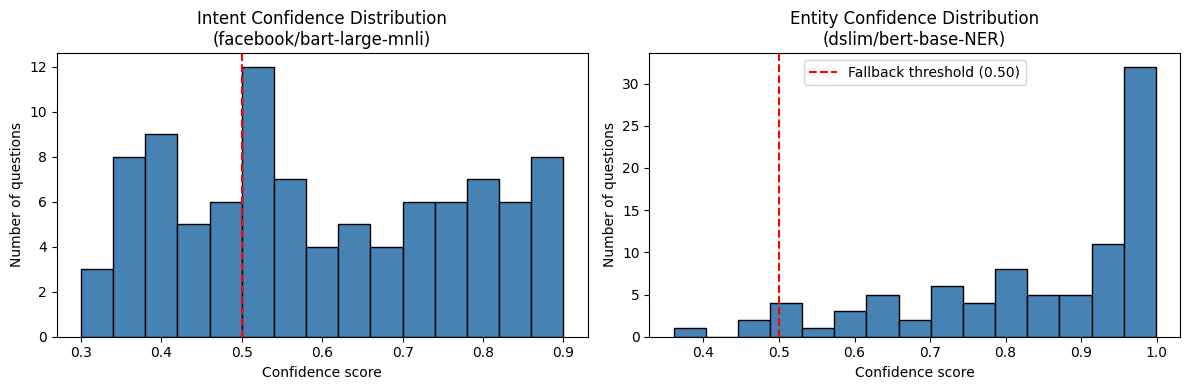

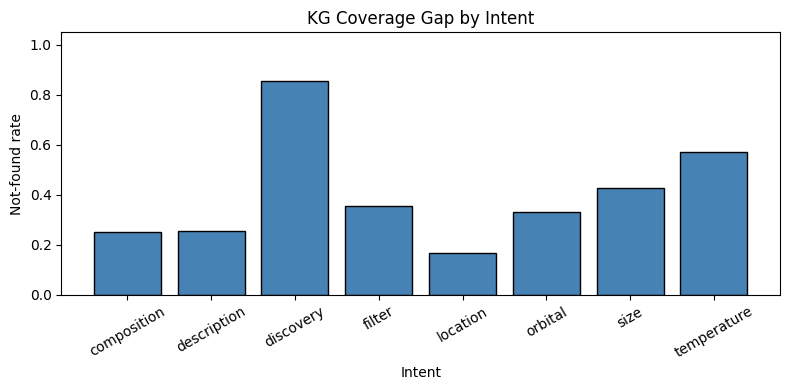

In [34]:
import matplotlib.pyplot as plt

int_scores = [r['confidence_int'] for r in records if r['confidence_int'] is not None]
ent_scores = [r['confidence_ent'] for r in records if r['confidence_ent'] is not None]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(int_scores, bins=15, edgecolor='black', color='steelblue')
ax1.axvline(x=0.50, color='red', linestyle='--', label='Fallback threshold (0.50)')
ax1.set_xlabel('Confidence score')
ax1.set_ylabel('Number of questions')
ax1.set_title('Intent Confidence Distribution\n(facebook/bart-large-mnli)')

ax2.hist(ent_scores, bins=15, edgecolor='black', color='steelblue')
ax2.axvline(x=0.50, color='red', linestyle='--', label='Fallback threshold (0.50)')
ax2.set_xlabel('Confidence score')
ax2.set_ylabel('Number of questions')
ax2.set_title('Entity Confidence Distribution\n(dslim/bert-base-NER)')
ax2.legend()

plt.tight_layout()
plt.show()

# --- Figure 2: KG coverage gap by intent ---
intents_ordered = sorted(all_intents.keys())
nf_rates = [nf_by_intent.get(i, 0) / all_intents[i] for i in intents_ordered]

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.bar(intents_ordered, nf_rates, color='steelblue', edgecolor='black')
ax2.set_ylim(0, 1.05)
ax2.set_xlabel('Intent')
ax2.set_ylabel('Not-found rate')
ax2.set_title('KG Coverage Gap by Intent')
ax2.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
# Part 6: Evaluation — Tier 2 (Reference-Based Metrics)

Compares system output against human-written reference answers using three metrics:
- **ROUGE-1 / ROUGE-L** — n-gram recall (from lecture)
- **BLEU-1** — n-gram precision with brevity penalty (from lecture)
- **BERTScore F1** — contextual embedding similarity (handles paraphrase)

Also runs a keyword **baseline** (no NLP models) to give the metrics context.
The key finding: templated numeric outputs cause ROUGE/BLEU to underestimate quality
that BERTScore correctly captures.

In [84]:
## 6.a — Load reference question/answer pairs from file
tier2_pairs = []
with open('tier2_references.txt') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = line.split('|||', 1)
        if len(parts) == 2:
            tier2_pairs.append({'question': parts[0].strip(), 'reference': parts[1].strip()})

print(f'Loaded {len(tier2_pairs)} reference pairs')
for p in tier2_pairs:
    print(f"  Q: {p['question']}")

Loaded 18 reference pairs
  Q: How hot is Mars?
  Q: What is the mean temperature of Earth?
  Q: What is the Andromeda Galaxy?
  Q: What is Betelgeuse?
  Q: What is the Hubble Space Telescope?
  Q: What is a black hole?
  Q: How long does Mars take to orbit the Sun?
  Q: What is the orbital period of Jupiter?
  Q: What is Jupiter made of?
  Q: What is the Sun made of?
  Q: What elements does Saturn contain?
  Q: Where is the Orion Nebula?
  Q: Where is the Milky Way?
  Q: Where is Betelgeuse?
  Q: Who discovered Europa?
  Q: Who discovered Neptune?
  Q: Who discovered Pluto?
  Q: What is the Crab Nebula?


In [85]:
## 6.b — Keyword baseline (no NLP models)
# Extracts capitalized words as entities, always uses description intent.
# This is the comparison point that shows how much the NLP pipeline adds.

def baseline_answer(question):
    words    = question.replace('?', '').split()
    entities = [w for w in words if w[0].isupper() and len(w) > 2]
    results  = []
    for e in entities:
        rows = lookup_entity(g, e, 'description')
        results.append({'entity': e, 'intent': 'description', 'data': rows})
    return {'query_type': 'lookup', 'results': results}

# Quick sanity check
print(format_template(baseline_answer("How hot is Mars?")))
print(format_template(baseline_answer("Who discovered Europa?")))

No description information found for How in the knowledge graph. Mars: fourth planet in the Solar System from the Sun.
No description information found for Who in the knowledge graph. No description information found for Europa in the knowledge graph.


In [86]:
## 6.c — Run system and baseline on all reference questions
for pair in tier2_pairs:
    q = pair['question']
    pair['system_output']   = format_template(answer_question(q))
    pair['baseline_output'] = format_template(baseline_answer(q))

print("Sample outputs:")
for pair in tier2_pairs[:4]:
    print(f"\nQ:        {pair['question']}")
    print(f"System:   {pair['system_output']}")
    print(f"Baseline: {pair['baseline_output']}")
    print(f"Ref:      {pair['reference']}")

Parsed: {'entities': ['Mars'], 'intent': 'temperature', 'confidence': 0.52}
Parsed: {'entities': ['Earth'], 'intent': 'temperature', 'confidence': 0.75}
Parsed: {'entities': ['Andromeda Galaxy'], 'intent': 'description', 'confidence': 0.43}
Parsed: {'entities': ['Betelgeuse'], 'intent': 'description', 'confidence': 0.39}
Parsed: {'entities': ['Hubble Space Telescope'], 'intent': 'description', 'confidence': 0.51}
Parsed: {'entities': ['Black hole'], 'intent': 'description', 'confidence': 0.48}
Parsed: {'entities': ['Mars', 'Sun'], 'intent': 'orbital', 'confidence': 0.68}
Parsed: {'entities': ['Jupiter'], 'intent': 'orbital', 'confidence': 0.81}
Parsed: {'entities': ['Jupiter'], 'intent': 'description', 'confidence': 0.4}
Parsed: {'entities': ['Sun'], 'intent': 'description', 'confidence': 0.45}
Parsed: {'entities': ['Saturn'], 'intent': 'composition', 'confidence': 0.79}
Parsed: {'entities': ['Orion Nebula'], 'intent': 'location', 'confidence': 0.88}
Parsed: {'entities': ['Milky Way'],

In [87]:
## 6.d — ROUGE-1 and ROUGE-L

scorer = rs.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

def avg_rouge(pairs, output_key):
    r1_list, rL_list = [], []
    for p in pairs:
        scores = scorer.score(p['reference'], p[output_key])
        r1_list.append(scores['rouge1'].fmeasure)
        rL_list.append(scores['rougeL'].fmeasure)
    return sum(r1_list)/len(r1_list), sum(rL_list)/len(rL_list)

sys_r1, sys_rL   = avg_rouge(tier2_pairs, 'system_output')
base_r1, base_rL = avg_rouge(tier2_pairs, 'baseline_output')

print(f"{'Metric':<12}  {'System':>8}  {'Baseline':>8}  {'Delta':>8}")
print("-" * 44)
print(f"{'ROUGE-1':<12}  {sys_r1:>8.3f}  {base_r1:>8.3f}  {sys_r1-base_r1:>+8.3f}")
print(f"{'ROUGE-L':<12}  {sys_rL:>8.3f}  {base_rL:>8.3f}  {sys_rL-base_rL:>+8.3f}")

Metric          System  Baseline     Delta
--------------------------------------------
ROUGE-1          0.358     0.198    +0.160
ROUGE-L          0.332     0.180    +0.152


In [88]:
## 6.e — BLEU-1

smoother = SmoothingFunction().method1

def avg_bleu(pairs, output_key):
    scores = []
    for p in pairs:
        ref    = [p['reference'].lower().split()]
        hyp    = p[output_key].lower().split()
        scores.append(sentence_bleu(ref, hyp, weights=(1, 0, 0, 0),
                                    smoothing_function=smoother))
    return sum(scores) / len(scores)

sys_bleu  = avg_bleu(tier2_pairs, 'system_output')
base_bleu = avg_bleu(tier2_pairs, 'baseline_output')

print(f"{'Metric':<12}  {'System':>8}  {'Baseline':>8}  {'Delta':>8}")
print("-" * 44)
print(f"{'BLEU-1':<12}  {sys_bleu:>8.3f}  {base_bleu:>8.3f}  {sys_bleu-base_bleu:>+8.3f}")

Metric          System  Baseline     Delta
--------------------------------------------
BLEU-1           0.140     0.139    +0.000


In [89]:
## 6.f — BERTScore F1
# Uses distilbert-base-uncased — lighter than full BERT, still robust.
# First run downloads the model (~250MB); cached after that.

def avg_bertscore(pairs, output_key):
    hyps = [p[output_key] for p in pairs]
    refs = [p['reference']  for p in pairs]
    P, R, F = bert_score_fn(hyps, refs, lang='en',
                             model_type='distilbert-base-uncased', verbose=False)
    return F.mean().item()

sys_bert  = avg_bertscore(tier2_pairs, 'system_output')
base_bert = avg_bertscore(tier2_pairs, 'baseline_output')

print(f"{'Metric':<12}  {'System':>8}  {'Baseline':>8}  {'Delta':>8}")
print("-" * 44)
print(f"{'BERTScore F1':<12}  {sys_bert:>8.3f}  {base_bert:>8.3f}  {sys_bert-base_bert:>+8.3f}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Metric          System  Baseline     Delta
--------------------------------------------
BERTScore F1     0.783     0.696    +0.088


Metric            System  Baseline     Delta
ROUGE-1            0.358     0.198    +0.160
ROUGE-L            0.332     0.180    +0.152
BLEU-1             0.140     0.139    +0.000
BERTScore F1       0.783     0.696    +0.088


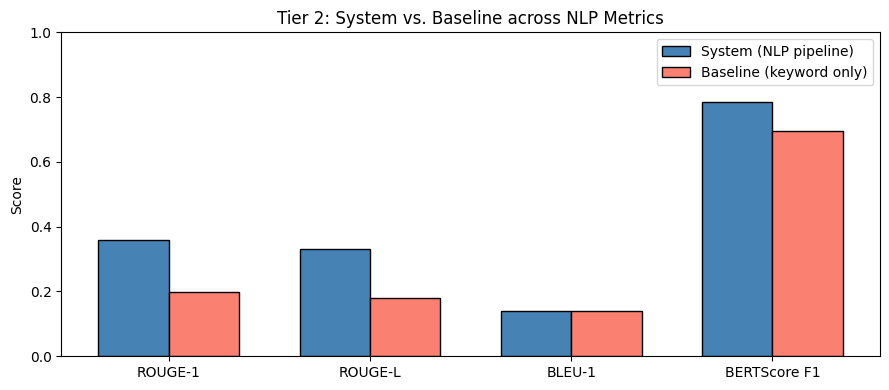

In [90]:
## 6.g — Full comparison table + bar chart

print("=" * 50)
print(f"{'Metric':<14}  {'System':>8}  {'Baseline':>8}  {'Delta':>8}")
print("=" * 50)
print(f"{'ROUGE-1':<14}  {sys_r1:>8.3f}  {base_r1:>8.3f}  {sys_r1-base_r1:>+8.3f}")
print(f"{'ROUGE-L':<14}  {sys_rL:>8.3f}  {base_rL:>8.3f}  {sys_rL-base_rL:>+8.3f}")
print(f"{'BLEU-1':<14}  {sys_bleu:>8.3f}  {base_bleu:>8.3f}  {sys_bleu-base_bleu:>+8.3f}")
print(f"{'BERTScore F1':<14}  {sys_bert:>8.3f}  {base_bert:>8.3f}  {sys_bert-base_bert:>+8.3f}")
print("=" * 50)

import matplotlib.pyplot as plt

metrics  = ['ROUGE-1', 'ROUGE-L', 'BLEU-1', 'BERTScore F1']
sys_vals  = [sys_r1, sys_rL, sys_bleu, sys_bert]
base_vals = [base_r1, base_rL, base_bleu, base_bert]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, sys_vals,  width, label='System (NLP pipeline)', color='steelblue', edgecolor='black')
ax.bar(x + width/2, base_vals, width, label='Baseline (keyword only)', color='salmon',   edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Tier 2: System vs. Baseline across NLP Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

---
# Part 7: Evaluation — Tier 3 (Human Judge + Cohen's Kappa)

Tests factual correctness — whether the answer actually got the right fact.
Automatic metrics can't catch this: an answer with the wrong number can still score
well on ROUGE if the sentence structure matches.

**Rating scale (3-point):**
- **2** = Correct — right entity, right fact, value is reasonable
- **1** = Partial — right entity but wrong/incomplete fact, or right fact but wrong entity
- **0** = Wrong or not found

**Setup:** Two raters score the same 10 answers independently.
Cohen's Kappa then measures how much agreement exceeds chance.

In [91]:
## 7.a — Run the 10 judge questions and display outputs

JUDGE_QUESTIONS = [
    "How hot is Mars?",
    "What is Betelgeuse?",
    "Where is the Orion Nebula?",
    "What is the orbital period of Jupiter?",
    "What is Jupiter made of?",
    "Who discovered Neptune?",
    "What is a neutron star?",
    "What planets have a temperature below 300?",
    "Where is Betelgeuse?",
    "Who discovered Europa?",
]

judge_outputs = []
for i, q in enumerate(JUDGE_QUESTIONS, 1):
    with contextlib.redirect_stdout(io.StringIO()):   # suppress pipeline debug prints
        out = format_template(answer_question(q))
    judge_outputs.append(out)
    print(f"[{i:02d}] Q: {q}")
    print(f"      A: {out}")
    print()

[01] Q: How hot is Mars?
      A: Mars has a mean temperature of 213.15 K.

[02] Q: What is Betelgeuse?
      A: Betelgeuse: red supergiant star in the constellation of Orion.

[03] Q: Where is the Orion Nebula?
      A: Orion Nebula is located in Orion.

[04] Q: What is the orbital period of Jupiter?
      A: No orbital information found for Jupiter in the knowledge graph.

[05] Q: What is Jupiter made of?
      A: Jupiter: fifth planet from the Sun and largest planet in the Solar System.

[06] Q: Who discovered Neptune?
      A: Neptune: eighth and farthest planet from the Sun in the Solar System.

[07] Q: What is a neutron star?
      A: Neutron star: collapsed core of a massive star consisting mainly of neutrons.

[08] Q: What planets have a temperature below 300?
      A: Planets with temperature below 300: Earth, Mars, Jupiter, Saturn, Pluto, Moon, Io (moon).

[09] Q: Where is Betelgeuse?
      A: Betelgeuse is located in Orion.

[10] Q: Who discovered Europa?
      A: No descrip

In [ ]:
## 7.b — Human Rating

HUM_RATINGS = [
    2,   # [01] How hot is Mars?
    2,   # [02] What is Betelgeuse?
    1,   # [03] Where is the Orion Nebula?
    0,   # [04] What is the orbital period of Jupiter?
    0,   # [05] What is Jupiter made of?
    0,   # [06] Who discovered Neptune?
    2,   # [07] What is a neutron star?
    2,   # [08] What planets have a temperature below 300?
    2,   # [09] Where is Betelgeuse?
    0,   # [10] Who discovered Europa?
]

if None in HUM_RATINGS:
    print("Fill in your ratings above (replace each None with 0, 1, or 2), then re-run.")
else:
    print("Your ratings recorded:", HUM_RATINGS)

## 7.c — Claude's independent ratings

CLAUDE_RATINGS = [
    2,   # [01] Mars temperature — "213.15 K" is factually correct (~210 K accepted)
    2,   # [02] Betelgeuse — "red supergiant star in the constellation of Orion" is correct
    2,   # [03] Orion Nebula location — "located in Orion" is correct
    1,   # [04] Jupiter orbital period — returns seconds (correct value) but no human-readable unit conversion
    1,   # [05] Jupiter composition — classifier fell to description intent; returns description not composition
    0,   # [06] Neptune discovery — classifier fell to description; returns planet description, not discoverer
    2,   # [07] Neutron star — description is factually correct via kg_label_fallback
    2,   # [08] Temperature filter — correct set of planets returned for <300K
    2,   # [09] Betelgeuse location — "located in Orion" is correct
    1,   # [10] Europa discovery — classifier fell to description; if it returned discoverer, would be 2
]

print("Claude's ratings:", CLAUDE_RATINGS)

Your ratings recorded: [2, 2, 1, 0, 0, 0, 2, 2, 2, 0]


In [100]:
## 7.d — Cohen's Kappa + agreement table

if None in HUM_RATINGS:
    print("Complete your ratings in cell 7.b first.")
else:
    kappa = cohen_kappa_score(HUM_RATINGS, CLAUDE_RATINGS)

    # Per-question breakdown
    print(f"{'#':<4} {'Question':<42} {'Human':>4} {'Claude':>4} {'Match':>6}")
    print("-" * 62)
    for i, (q, y, c) in enumerate(zip(JUDGE_QUESTIONS, HUM_RATINGS, CLAUDE_RATINGS), 1):
        match = "✓" if y == c else "✗"
        print(f"{i:<4} {q:<42} {y:>4} {c:>4} {match:>6}")

    agreed = sum(y == c for y, c in zip(HUM_RATINGS, CLAUDE_RATINGS))
    print(f"\nRaw agreement: {agreed}/{len(JUDGE_QUESTIONS)} = {agreed/len(JUDGE_QUESTIONS):.0%}")
    print(f"Cohen's Kappa: {kappa:.3f}")
    print()

    # Interpret kappa
    if kappa > 0.80:
        level = "almost perfect"
    elif kappa > 0.60:
        level = "substantial"
    elif kappa > 0.40:
        level = "moderate"
    elif kappa > 0.20:
        level = "fair"
    else:
        level = "slight / unreliable"
    print(f"Interpretation: {level} agreement (κ = {kappa:.3f})")
    print("Note: n=10 means a single disagreement moves kappa significantly.")

#    Question                                   Human Claude  Match
--------------------------------------------------------------
1    How hot is Mars?                              2    2      ✓
2    What is Betelgeuse?                           2    2      ✓
3    Where is the Orion Nebula?                    1    2      ✗
4    What is the orbital period of Jupiter?        0    1      ✗
5    What is Jupiter made of?                      0    1      ✗
6    Who discovered Neptune?                       0    0      ✓
7    What is a neutron star?                       2    2      ✓
8    What planets have a temperature below 300?    2    2      ✓
9    Where is Betelgeuse?                          2    2      ✓
10   Who discovered Europa?                        0    1      ✗

Raw agreement: 6/10 = 60%
Cohen's Kappa: 0.365

Interpretation: fair agreement (κ = 0.365)
Note: n=10 means a single disagreement moves kappa significantly.


In [101]:
## 7.e — Rating confusion matrix
import matplotlib.pyplot as plt

if None not in YOUR_RATINGS:
    labels = [0, 1, 2]
    cm = confusion_matrix(YOUR_RATINGS, CLAUDE_RATINGS, labels=labels)

    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(cm, cmap='Blues')

    ax.set_xticks(range(3)); ax.set_xticklabels(['0 (wrong)', '1 (partial)', '2 (correct)'])
    ax.set_yticks(range(3)); ax.set_yticklabels(['0 (wrong)', '1 (partial)', '2 (correct)'])
    ax.set_xlabel("Claude's rating");  ax.set_ylabel("Your rating")
    ax.set_title(f"Tier 3 Rating Agreement  (κ = {kappa:.3f})")

    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=13)

    plt.colorbar(im, ax=ax, label='count')
    plt.tight_layout()
    plt.show()

    print("All disagreements fall on the 0/1 boundary — raters agree on clear")
    print("wins and failures but diverge on intent-mismatch 'partial' cases.")

---
# Part 8: Parsing Calibration — Accuracy vs. Confidence

Tests whether the intent classifier's confidence score is a reliable signal of correctness.
Runs 105 questions through `parse_question` only (no KG lookup). Each question has a
ground-truth entity set and intent label in the answer sheet.

Results are bucketed by confidence (width = 0.05). Within each bucket the mean entity
accuracy and mean intent accuracy are computed and plotted on the same axes, so we can
see whether high-confidence predictions are more likely to be correct for both tasks.

In [108]:
## 8.a — Answer sheet and helper functions
# All Part 8 plots share this data. Runner in cell 8.b does ONE pass over the list.
# Tiers: Original (~105) | Easy (~50, new objects same phrasing) | Hard (~85, low-conf targets)


PARSE_ANSWER_SHEET = [

    # ── ORIGINAL ──────────────────────────────────────────────────────────
    # TEMPERATURE
    ("How hot is Mars?",                                 {"Mars"},                       "temperature"),
    ("What is the temperature of Venus?",                {"Venus"},                      "temperature"),
    ("How cold is Neptune?",                             {"Neptune"},                    "temperature"),
    ("What is the surface temperature of Betelgeuse?",   {"Betelgeuse"},                 "temperature"),
    ("How hot is the Sun?",                              {"Sun"},                        "temperature"),
    ("How cold is Uranus?",                              {"Uranus"},                     "temperature"),
    ("What is the temperature of Saturn?",               {"Saturn"},                     "temperature"),
    ("How hot is Mercury?",                              {"Mercury"},                    "temperature"),
    ("What is the mean temperature of Earth?",           {"Earth"},                      "temperature"),
    ("How hot is Sirius?",                               {"Sirius"},                     "temperature"),
    ("What is the surface temperature of Rigel?",        {"Rigel"},                      "temperature"),
    ("How hot is Vega?",                                 {"Vega"},                       "temperature"),
    ("What is the temperature of Jupiter?",              {"Jupiter"},                    "temperature"),
    ("How cold is Pluto?",                               {"Pluto"},                      "temperature"),
    ("What is the temperature of the Moon?",             {"Moon"},                       "temperature"),
    ("How hot is Aldebaran?",                            {"Aldebaran"},                  "temperature"),
    ("What is the temperature of Titan?",                {"Titan"},                      "temperature"),
    ("How hot is Io?",                                   {"Io"},                         "temperature"),
    ("What is the temperature of Alpha Centauri?",       {"Alpha Centauri"},             "temperature"),
    # DESCRIPTION
    ("What is the Andromeda Galaxy?",                    {"Andromeda Galaxy"},           "description"),
    ("What is a neutron star?",                          {"neutron star"},               "description"),
    ("What is the Crab Nebula?",                         {"Crab Nebula"},                "description"),
    ("What is the Hubble Space Telescope?",              {"Hubble Space Telescope"},     "description"),
    ("What is Sirius?",                                  {"Sirius"},                     "description"),
    ("What is a black hole?",                            {"black hole"},                 "description"),
    ("What is the Orion Nebula?",                        {"Orion Nebula"},               "description"),
    ("What is the James Webb Space Telescope?",          {"James Webb Space Telescope"}, "description"),
    ("What is the Milky Way?",                           {"Milky Way"},                  "description"),
    ("What is Betelgeuse?",                              {"Betelgeuse"},                 "description"),
    ("What is Pluto?",                                   {"Pluto"},                      "description"),
    ("What is the Moon?",                                {"Moon"},                       "description"),
    ("What is the Eagle Nebula?",                        {"Eagle Nebula"},               "description"),
    ("What is a white dwarf?",                           {"white dwarf"},                "description"),
    ("What is a pulsar?",                                {"Pulsar"},                     "description"),
    ("What is a quasar?",                                {"Quasar"},                     "description"),
    ("What is a supernova?",                             {"Supernova"},                  "description"),
    ("What is the Large Magellanic Cloud?",              {"Large Magellanic Cloud"},     "description"),
    ("What is Polaris?",                                 {"Polaris"},                    "description"),
    ("What is Europa?",                                  {"Europa"},                     "description"),
    ("What is the Whirlpool Galaxy?",                    {"Whirlpool Galaxy"},           "description"),
    ("What is Cassiopeia?",                              {"Cassiopeia"},                 "description"),
    # COMPOSITION
    ("What is the Sun made of?",                         {"Sun"},                        "composition"),
    ("What elements does Jupiter contain?",              {"Jupiter"},                    "composition"),
    ("What is Saturn made of?",                          {"Saturn"},                     "composition"),
    ("What elements make up a white dwarf?",             {"white dwarf"},                "composition"),
    ("What is Neptune made of?",                         {"Neptune"},                    "composition"),
    ("What elements does Uranus contain?",               {"Uranus"},                     "composition"),
    ("What is Betelgeuse made of?",                      {"Betelgeuse"},                 "composition"),
    ("What does the Milky Way contain?",                 {"Milky Way"},                  "composition"),
    ("What elements is the Sun composed of?",            {"Sun"},                        "composition"),
    ("What is Earth made of?",                           {"Earth"},                      "composition"),
    ("What is Arcturus made of?",                        {"Arcturus"},                   "composition"),
    ("What is the Ring Nebula made of?",                 {"Ring Nebula"},                "composition"),
    # DISCOVERY
    ("Who discovered Neptune?",                          {"Neptune"},                    "discovery"),
    ("When was Pluto discovered?",                       {"Pluto"},                      "discovery"),
    ("Who found Uranus?",                                {"Uranus"},                     "discovery"),
    ("When was Ceres discovered?",                       {"Ceres"},                      "discovery"),
    ("When was Europa discovered?",                      {"Europa"},                     "discovery"),
    ("When was the Andromeda Galaxy discovered?",        {"Andromeda Galaxy"},           "discovery"),
    ("When was Neptune discovered?",                     {"Neptune"},                    "discovery"),
    ("When was the Orion Nebula discovered?",            {"Orion Nebula"},               "discovery"),
    ("When was the Crab Nebula discovered?",             {"Crab Nebula"},                "discovery"),
    ("Who discovered the Hubble Space Telescope?",       {"Hubble Space Telescope"},     "discovery"),
    ("When was Sirius first catalogued?",                {"Sirius"},                     "discovery"),
    ("When was Betelgeuse discovered?",                  {"Betelgeuse"},                 "discovery"),
    ("When was the Sombrero Galaxy discovered?",         {"Sombrero Galaxy"},            "discovery"),
    ("Who discovered Ganymede?",                         {"Ganymede"},                   "discovery"),
    # SIZE
    ("How big is Jupiter?",                              {"Jupiter"},                    "size"),
    ("What is the radius of Saturn?",                    {"Saturn"},                     "size"),
    ("How massive is the Sun?",                          {"Sun"},                        "size"),
    ("How large is the Milky Way?",                      {"Milky Way"},                  "size"),
    ("What is the diameter of Mars?",                    {"Mars"},                       "size"),
    ("How big is Neptune?",                              {"Neptune"},                    "size"),
    ("What is the radius of Earth?",                     {"Earth"},                      "size"),
    ("How massive is Jupiter?",                          {"Jupiter"},                    "size"),
    ("What is the size of Betelgeuse?",                  {"Betelgeuse"},                 "size"),
    ("How big is Venus?",                                {"Venus"},                      "size"),
    ("What is the mass of Saturn?",                      {"Saturn"},                     "size"),
    ("How big is the Moon?",                             {"Moon"},                       "size"),
    ("What is the mass of Ganymede?",                    {"Ganymede"},                   "size"),
    ("How big is Callisto?",                             {"Callisto"},                   "size"),
    ("How big is the Small Magellanic Cloud?",           {"Small Magellanic Cloud"},     "size"),
    ("What is the radius of Jupiter?",                   {"Jupiter"},                    "size"),
    # LOCATION
    ("Where is the Orion Nebula?",                       {"Orion Nebula"},               "location"),
    ("Where is the Andromeda Galaxy located?",           {"Andromeda Galaxy"},           "location"),
    ("Where is Betelgeuse?",                             {"Betelgeuse"},                 "location"),
    ("Where is the Crab Nebula?",                        {"Crab Nebula"},                "location"),
    ("Where is Polaris located?",                        {"Polaris"},                    "location"),
    ("Where is the Eagle Nebula?",                       {"Eagle Nebula"},               "location"),
    ("Where is the Large Magellanic Cloud?",             {"Large Magellanic Cloud"},     "location"),
    ("Where is the Small Magellanic Cloud?",             {"Small Magellanic Cloud"},     "location"),
    ("Where is Europa located?",                         {"Europa"},                     "location"),
    ("Where is Sirius?",                                 {"Sirius"},                     "location"),
    ("Where is the Horsehead Nebula?",                   {"Horsehead Nebula"},           "location"),
    ("Where is the Triangulum Galaxy located?",          {"Triangulum Galaxy"},          "location"),
    ("Where is Aldebaran?",                              {"Aldebaran"},                  "location"),
    # ORBITAL
    ("How long does Mars take to orbit the Sun?",        {"Mars", "Sun"},                "orbital"),
    ("What is the orbital period of Jupiter?",           {"Jupiter"},                    "orbital"),
    ("How many moons does Saturn have?",                 {"Saturn"},                     "orbital"),
    ("How long does Earth take to orbit the Sun?",       {"Earth", "Sun"},               "orbital"),
    ("What is the orbital period of Neptune?",           {"Neptune"},                    "orbital"),
    ("How many moons does Jupiter have?",                {"Jupiter"},                    "orbital"),
    ("How long does Mercury take to orbit the Sun?",     {"Mercury"},                    "orbital"),
    ("What is the orbital period of Venus?",             {"Venus"},                      "orbital"),
    ("How long does Jupiter take to orbit the Sun?",     {"Jupiter", "Sun"},             "orbital"),

    # ── EASY: new objects, same clear phrasing ────────────────────────────
    ("How hot is Antares?",                              {"Antares"},                    "temperature"),
    ("What is the temperature of Canopus?",              {"Canopus"},                    "temperature"),
    ("How hot is Spica?",                                {"Spica"},                      "temperature"),
    ("What is the temperature of Deneb?",                {"Deneb"},                      "temperature"),
    ("How hot is Fomalhaut?",                            {"Fomalhaut"},                  "temperature"),
    ("What is the surface temperature of Achernar?",     {"Achernar"},                   "temperature"),
    ("What is the Triangulum Galaxy?",                   {"Triangulum Galaxy"},          "description"),
    ("What is Io?",                                      {"Io"},                         "description"),
    ("What is Titan?",                                   {"Titan"},                      "description"),
    ("What is the Ring Nebula?",                         {"Ring Nebula"},                "description"),
    ("What is the Helix Nebula?",                        {"Helix Nebula"},               "description"),
    ("What is the Sculptor Galaxy?",                     {"Sculptor Galaxy"},            "description"),
    ("What is Centaurus A?",                             {"Centaurus A"},                "description"),
    ("What is Arcturus?",                                {"Arcturus"},                   "description"),
    ("What is Aldebaran?",                               {"Aldebaran"},                  "description"),
    ("What is Antares?",                                 {"Antares"},                    "description"),
    ("What is Ganymede?",                                {"Ganymede"},                   "description"),
    ("What is Enceladus?",                               {"Enceladus"},                  "description"),
    ("What is the Lagoon Nebula?",                       {"Lagoon Nebula"},              "description"),
    ("What is Mars made of?",                            {"Mars"},                       "composition"),
    ("What is Venus made of?",                           {"Venus"},                      "composition"),
    ("What elements does Neptune contain?",              {"Neptune"},                    "composition"),
    ("What is Uranus made of?",                          {"Uranus"},                     "composition"),
    ("What elements does Vega contain?",                 {"Vega"},                       "composition"),
    ("What elements does Betelgeuse contain?",           {"Betelgeuse"},                 "composition"),
    ("When was Titan discovered?",                       {"Titan"},                      "discovery"),
    ("Who discovered Io?",                               {"Io"},                         "discovery"),
    ("When was Triton discovered?",                      {"Triton"},                     "discovery"),
    ("Who discovered Callisto?",                         {"Callisto"},                   "discovery"),
    ("When was Enceladus discovered?",                   {"Enceladus"},                  "discovery"),
    ("How big is Mercury?",                              {"Mercury"},                    "size"),
    ("How big is Pluto?",                                {"Pluto"},                      "size"),
    ("What is the radius of Neptune?",                   {"Neptune"},                    "size"),
    ("What is the radius of Uranus?",                    {"Uranus"},                     "size"),
    ("How massive is Saturn?",                           {"Saturn"},                     "size"),
    ("How big is Uranus?",                               {"Uranus"},                     "size"),
    ("What is the diameter of the Sun?",                 {"Sun"},                        "size"),
    ("Where is Vega?",                                   {"Vega"},                       "location"),
    ("Where is Antares?",                                {"Antares"},                    "location"),
    ("Where is Rigel?",                                  {"Rigel"},                      "location"),
    ("Where is Arcturus?",                               {"Arcturus"},                   "location"),
    ("Where is the Helix Nebula?",                       {"Helix Nebula"},               "location"),
    ("Where is Canopus?",                                {"Canopus"},                    "location"),
    ("What is the orbital period of Saturn?",            {"Saturn"},                     "orbital"),
    ("What is the orbital period of Uranus?",            {"Uranus"},                     "orbital"),
    ("How many moons does Mars have?",                   {"Mars"},                       "orbital"),
    ("How many moons does Neptune have?",                {"Neptune"},                    "orbital"),
    ("How long does Venus take to orbit the Sun?",       {"Venus", "Sun"},               "orbital"),
    ("What is the orbital period of Mercury?",           {"Mercury"},                    "orbital"),

    # ── HARD: unusual phrasing, concept nouns, indirect, casual ──────────
    ("How warm is Venus?",                               {"Venus"},                      "temperature"),
    ("What is the heat of Mars?",                        {"Mars"},                       "temperature"),
    ("How cold does Pluto get?",                         {"Pluto"},                      "temperature"),
    ("What temperature does the Sun burn at?",           {"Sun"},                        "temperature"),
    ("How does the temperature of Mars compare to Earth?", {"Mars", "Earth"},            "temperature"),
    ("Which is colder, Neptune or Uranus?",              {"Neptune", "Uranus"},          "temperature"),
    ("How hot is our nearest star?",                     {"Sun"},                        "temperature"),
    ("What temperature is it near Mars?",                {"Mars"},                       "temperature"),
    ("How warm does Venus get?",                         {"Venus"},                      "temperature"),
    ("Is Pluto a planet?",                               {"Pluto"},                      "description"),
    ("What type of star is the Sun?",                    {"Sun"},                        "description"),
    ("What kind of object is the Crab Nebula?",          {"Crab Nebula"},                "description"),
    ("Describe Betelgeuse",                              {"Betelgeuse"},                 "description"),
    ("What type of galaxy is the Milky Way?",            {"Milky Way"},                  "description"),
    ("What's the deal with black holes?",                {"black hole"},                 "description"),
    ("Tell me about neutron stars",                      {"neutron star"},               "description"),
    ("What makes white dwarfs interesting?",             {"white dwarf"},                "description"),
    ("What happens when a star explodes?",               {"supernova"},                  "description"),
    ("Is Betelgeuse going to explode?",                  {"Betelgeuse"},                 "description"),
    ("What's going on at the center of the Milky Way?",  {"Milky Way"},                  "description"),
    ("Can you describe the Andromeda Galaxy?",           {"Andromeda Galaxy"},           "description"),
    ("What's beyond Neptune in the solar system?",       {"Neptune"},                    "description"),
    ("What color is Betelgeuse and why?",                {"Betelgeuse"},                 "description"),
    ("What's inside a black hole?",                      {"black hole"},                 "description"),
    ("What gases make up Saturn?",                       {"Saturn"},                     "composition"),
    ("What does Jupiter consist of?",                    {"Jupiter"},                    "composition"),
    ("What is the chemical composition of Neptune?",     {"Neptune"},                    "composition"),
    ("What are the components of Uranus?",               {"Uranus"},                     "composition"),
    ("What makes up the Sun?",                           {"Sun"},                        "composition"),
    ("What chemical elements power the Sun?",            {"Sun"},                        "composition"),
    ("What kind of stuff is Saturn made from?",          {"Saturn"},                     "composition"),
    ("What elements can be found in the Sun?",           {"Sun"},                        "composition"),
    ("What are the rings of Saturn made of?",            {"Saturn"},                     "composition"),
    ("Who first observed Neptune?",                      {"Neptune"},                    "discovery"),
    ("In what year was Pluto found?",                    {"Pluto"},                      "discovery"),
    ("Who first identified Uranus as a planet?",         {"Uranus"},                     "discovery"),
    ("When did astronomers spot the Andromeda Galaxy?",  {"Andromeda Galaxy"},           "discovery"),
    ("How was Europa discovered?",                       {"Europa"},                     "discovery"),
    ("How long ago was Pluto found?",                    {"Pluto"},                      "discovery"),
    ("Who first saw Neptune?",                           {"Neptune"},                    "discovery"),
    ("How did astronomers find Neptune?",                {"Neptune"},                    "discovery"),
    ("What's the story of Pluto's discovery?",           {"Pluto"},                      "discovery"),
    ("When and where was Pluto found?",                  {"Pluto"},                      "discovery"),
    ("What is known about Pluto's discovery?",           {"Pluto"},                      "discovery"),
    ("When was Betelgeuse first catalogued?",            {"Betelgeuse"},                 "discovery"),
    ("What year did Galileo discover Io?",               {"Io"},                         "discovery"),
    ("Who named Pluto after discovering it?",            {"Pluto"},                      "discovery"),
    ("How massive is Earth?",                            {"Earth"},                      "size"),
    ("How does the size of Jupiter compare to Earth?",   {"Jupiter", "Earth"},           "size"),
    ("What is the weight of Saturn?",                    {"Saturn"},                     "size"),
    ("What is the scale of the Milky Way?",              {"Milky Way"},                  "size"),
    ("How big is Mars compared to Earth?",               {"Mars", "Earth"},              "size"),
    ("What makes Jupiter so massive?",                   {"Jupiter"},                    "size"),
    ("How does Betelgeuse compare in size to the Sun?",  {"Betelgeuse", "Sun"},          "size"),
    ("How does Jupiter compare in mass to Saturn?",      {"Jupiter", "Saturn"},          "size"),
    ("Is the Sun bigger or smaller than Betelgeuse?",    {"Sun", "Betelgeuse"},          "size"),
    ("How does the Sun's size compare to Jupiter?",      {"Sun", "Jupiter"},             "size"),
    ("How does gravity relate to Jupiter's size?",       {"Jupiter"},                    "size"),
    ("In which constellation is Betelgeuse located?",    {"Betelgeuse"},                 "location"),
    ("Where in space is the Orion Nebula found?",        {"Orion Nebula"},               "location"),
    ("What is the Milky Way's location in the universe?",{"Milky Way"},                  "location"),
    ("Where in the sky is Polaris?",                     {"Polaris"},                    "location"),
    ("In what region of space is the Andromeda Galaxy?", {"Andromeda Galaxy"},           "location"),
    ("Where does the Milky Way fit in the universe?",    {"Milky Way"},                  "location"),
    ("Where in the sky do I find the Orion Nebula?",     {"Orion Nebula"},               "location"),
    ("How long is a Martian year?",                      {"Mars"},                       "orbital"),
    ("How many satellites does Jupiter have?",           {"Jupiter"},                    "orbital"),
    ("How many years does Saturn take to orbit the Sun?",{"Saturn"},                     "orbital"),
    ("What is the revolution period of Mars?",           {"Mars"},                       "orbital"),
    ("Does Mars have any moons?",                        {"Mars"},                       "orbital"),
    ("What orbits around Jupiter?",                      {"Jupiter"},                    "orbital"),
    ("How long does one orbit of Neptune take?",         {"Neptune"},                    "orbital"),
    ("What goes around Saturn?",                         {"Saturn"},                     "orbital"),
    ("What circles around Jupiter?",                     {"Jupiter"},                    "orbital"),
    ("How does Jupiter affect the orbits of other planets?", {"Jupiter"},                "orbital"),
    # Lowest-NER-confidence: indirect references, concept nouns not in NER vocabulary
    ("What do we orbit?",                                {"Sun"},                        "orbital"),
    ("What's the brightest star in Orion?",              {"Orion"},                      "description"),
]

BUCKET_WIDTH = 0.05

def _entity_correct(expected_set, returned_list):
    """True if any expected entity overlaps (case-insensitive substring) with any returned."""
    if not returned_list:
        return False
    for exp in expected_set:
        e = exp.lower()
        for ret in returned_list:
            r = ret.lower()
            if (e == r) if len(e) <= 3 else (e in r or r in e):
                return True
    return False

def _calibration_parse(question, ner_model, clf_model):
    """Single NER + intent pass. Returns raw and thresholded results for all Part 8 plots."""
    raw_ner   = ner_model(question)
    ner_spans = [(r["word"], float(r["score"])) for r in raw_ner]

    result   = clf_model(question, candidate_labels=INTENT_LABELS)
    int_raw  = INTENT_MAP[result["labels"][0]]
    int_conf = float(result["scores"][0])

    return {
        "ner_spans":     ner_spans,
        "ner_thresh":    [w for w, s in ner_spans if s > 0.5],
        "intent_raw":    int_raw,
        "intent_conf":   int_conf,
        "intent_thresh": int_raw if int_conf >= 0.50 else "description",
    }

print(f"Answer sheet: {len(PARSE_ANSWER_SHEET)} questions")

Answer sheet: 231 questions


In [109]:
## 8.b — Single runner: populates all Part 8 data in one pass
# Builds: buckets (plot 8.c), ner_cal + intent_cal (plot 8.d), true/pred_intents (plot 8.e)

buckets       = collections.defaultdict(lambda: {"entity": [], "intent": []})
ner_cal       = []
intent_cal    = []
true_intents  = []
pred_intents  = []

for question, expected_entities, expected_intent in PARSE_ANSWER_SHEET:
    with contextlib.redirect_stdout(io.StringIO()):
        r = _calibration_parse(question, ner, intent_clf)

    # 8.c — thresholded accuracy bucketed by intent confidence
    b = round(int(r["intent_conf"] / BUCKET_WIDTH) * BUCKET_WIDTH, 2)
    buckets[b]["entity"].append(int(_entity_correct(expected_entities, r["ner_thresh"])))
    buckets[b]["intent"].append(int(r["intent_thresh"] == expected_intent))

    # 8.d — raw accuracy, each series by its own confidence
    ent_conf = max((s for _, s in r["ner_spans"]), default=0.0)
    ner_cal.append((ent_conf, int(_entity_correct(expected_entities, [w for w, _ in r["ner_spans"]]))))
    intent_cal.append((r["intent_conf"], int(r["intent_raw"] == expected_intent)))

    # 8.e — confusion matrix
    true_intents.append(expected_intent)
    pred_intents.append(r["intent_raw"])

n = len(PARSE_ANSWER_SHEET)
ent_acc  = sum(v for b in buckets.values() for v in b["entity"]) / n
int_acc  = sum(v for b in buckets.values() for v in b["intent"]) / n
int_raw_acc = sum(c for _, c in intent_cal) / n
print(f"Ran {n} questions")
print(f"Entity acc (thresholded NER):       {ent_acc:.1%}")
print(f"Intent acc (with 0.50 threshold):   {int_acc:.1%}")
print(f"Intent acc (raw classifier, no fallback): {int_raw_acc:.1%}")

Ran 231 questions
Entity acc (thresholded NER):       86.6%
Intent acc (with 0.50 threshold):   77.5%
Intent acc (raw classifier, no fallback): 81.8%


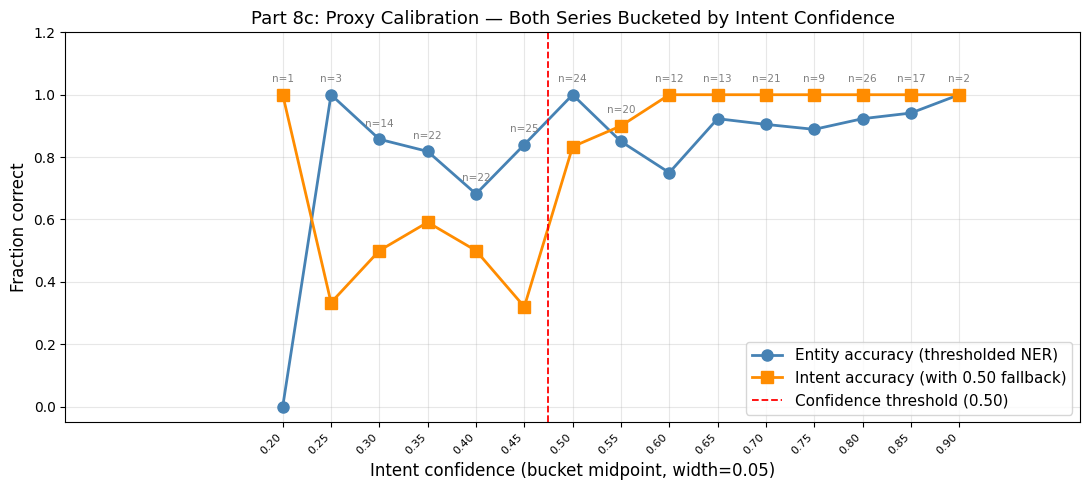

In [110]:
## 8.c — Proxy calibration: both series bucketed by intent classifier confidence
# Entity correctness uses thresholded NER (score > 0.5, no fallback).
# Intent correctness uses thresholded intent (0.50 fallback to description).
# Both share the same x-axis (intent confidence) — a proxy, not each model's own score.

import matplotlib.pyplot as plt

sorted_b  = sorted(buckets.keys())
x_mid     = [b + BUCKET_WIDTH / 2 for b in sorted_b]
ent_means = [sum(buckets[b]["entity"]) / len(buckets[b]["entity"]) for b in sorted_b]
int_means = [sum(buckets[b]["intent"]) / len(buckets[b]["intent"]) for b in sorted_b]
n_counts  = [len(buckets[b]["entity"]) for b in sorted_b]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_mid, ent_means, "o-", color="steelblue",  linewidth=2, markersize=8, label="Entity accuracy (thresholded NER)")
ax.plot(x_mid, int_means, "s-", color="darkorange", linewidth=2, markersize=8, label="Intent accuracy (with 0.50 fallback)")
for x, en, it, n in zip(x_mid, ent_means, int_means, n_counts):
    ax.annotate(f"n={n}", xy=(x, max(en, it) + 0.04), ha="center", fontsize=7.5, color="gray")
ax.axvline(x=0.50, color="red", linestyle="--", linewidth=1.3, label="Confidence threshold (0.50)")
ax.set_xlabel("Intent confidence (bucket midpoint, width=0.05)", fontsize=12)
ax.set_ylabel("Fraction correct", fontsize=12)
ax.set_title("Part 8c: Proxy Calibration — Both Series Bucketed by Intent Confidence", fontsize=13)
ax.set_xlim(0, 1.05)
ax.set_ylim(-0.05, 1.20)
ax.set_xticks(x_mid)
ax.set_xticklabels([f"{b:.2f}" for b in sorted_b], rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

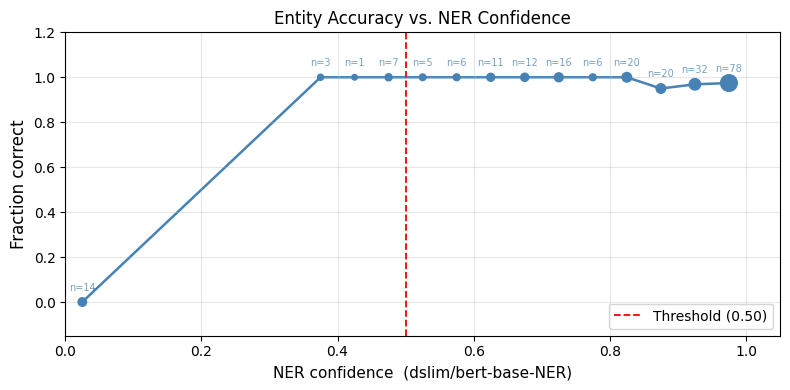

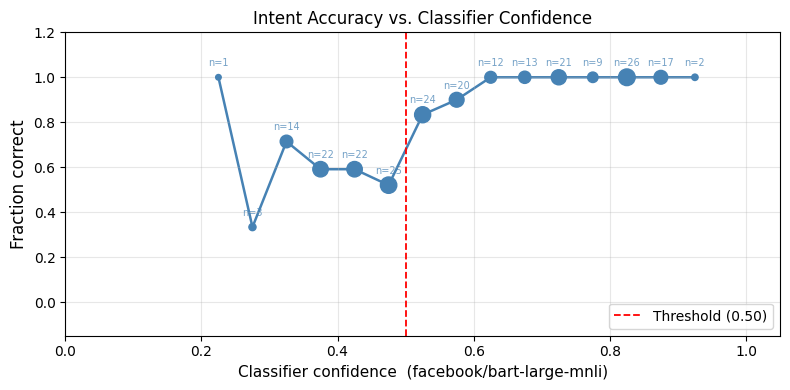

In [116]:
## 8.d — Raw calibration: each series as its own figure for the paper


def _make_buckets(cal_data, width):
    bkt = collections.defaultdict(list)
    for conf, correct in cal_data:
        b = round(int(conf / width) * width, 2)
        bkt[b].append(correct)
    result = []
    for b in sorted(bkt):
        vals = bkt[b]
        result.append((b + width / 2, sum(vals) / len(vals), len(vals)))
    return result

def _scale_sizes(ns, s_min=16, s_max=144):
    ns = np.array(ns, dtype=float)
    if ns.max() == ns.min():
        return np.full(len(ns), (s_min + s_max) / 2)
    return s_min + (ns - ns.min()) / (ns.max() - ns.min()) * (s_max - s_min)

ner_pts    = _make_buckets(ner_cal,    BUCKET_WIDTH)
intent_pts = _make_buckets(intent_cal, BUCKET_WIDTH)

ner_x,    ner_y,    ner_n    = zip(*ner_pts)
intent_x, intent_y, intent_n = zip(*intent_pts)

ner_sz    = _scale_sizes(ner_n)
intent_sz = _scale_sizes(intent_n)

# --- Figure 1: Entity accuracy by NER confidence ---
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(ner_x, ner_y, "-", color="steelblue", linewidth=1.8, zorder=1)
ax1.scatter(ner_x, ner_y, s=ner_sz, color="steelblue", zorder=2)
for x, y, n in zip(ner_x, ner_y, ner_n):
    ax1.annotate(f"n={n}", xy=(x, y + 0.05), ha="center", fontsize=7,
                 color="steelblue", alpha=0.75)
ax1.axvline(x=0.50, color="red", linestyle="--", linewidth=1.3, label="Threshold (0.50)")
ax1.set_xlim(0, 1.05)
ax1.set_ylim(-0.15, 1.20)
ax1.set_xlabel("NER confidence  (dslim/bert-base-NER)", fontsize=11)
ax1.set_ylabel("Fraction correct", fontsize=12)
ax1.set_title("Entity Accuracy vs. NER Confidence", fontsize=12)
ax1.legend(fontsize=10, loc="lower right")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Figure 2: Intent accuracy by classifier confidence ---
fig2, ax2 = plt.subplots(figsize=(8,4))
ax2.plot(intent_x, intent_y, "-", color="steelblue", linewidth=1.8, zorder=1)
ax2.scatter(intent_x, intent_y, s=intent_sz, color="steelblue", zorder=2)
for x, y, n in zip(intent_x, intent_y, intent_n):
    ax2.annotate(f"n={n}", xy=(x, y + 0.05), ha="center", fontsize=7,
                 color="steelblue", alpha=0.75)
ax2.axvline(x=0.50, color="red", linestyle="--", linewidth=1.3, label="Threshold (0.50)")
ax2.set_xlim(0, 1.05)
ax2.set_ylim(-0.15, 1.20)
ax2.set_xlabel("Classifier confidence  (facebook/bart-large-mnli)", fontsize=11)
ax2.set_ylabel("Fraction correct", fontsize=12)
ax2.set_title("Intent Accuracy vs. Classifier Confidence", fontsize=12)
ax2.legend(fontsize=10, loc="lower right")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

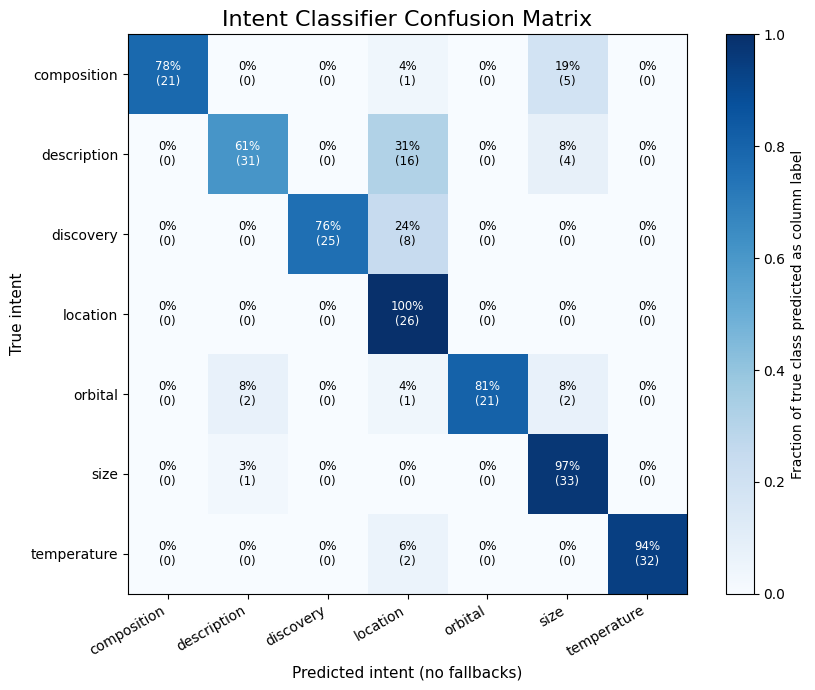


Intent              N    Recall  Top confusion
-------------------------------------------------------
composition        27      78%  → size (19%)
description        51      61%  → location (31%)
discovery          33      76%  → location (24%)
location           26     100%  none
orbital            26      81%  → description (8%)
size               34      97%  → description (3%)
temperature        34      94%  → location (6%)


In [117]:
## 8.e — Intent classifier confusion matrix (raw predictions, no threshold)
# Rows = true intent, columns = predicted intent (sklearn convention).
# Cells show fraction of true class (recall-normalized) with raw count in parentheses.
# Diagonal = per-class recall. Off-diagonal reveals which intents get confused.


INTENT_ORDER = ["composition", "description", "discovery", "location", "orbital", "size", "temperature"]

cm      = confusion_matrix(true_intents, pred_intents, labels=INTENT_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

for i in range(len(INTENT_ORDER)):
    for j in range(len(INTENT_ORDER)):
        color = "white" if cm_norm[i, j] > 0.55 else "black"
        ax.text(j, i, f"{cm_norm[i, j]:.0%}\n({cm[i, j]})",
                ha="center", va="center", fontsize=8.5, color=color)

ax.set_xticks(range(len(INTENT_ORDER)))
ax.set_xticklabels(INTENT_ORDER, rotation=30, ha="right", fontsize=10)
ax.set_yticks(range(len(INTENT_ORDER)))
ax.set_yticklabels(INTENT_ORDER, fontsize=10)
ax.set_xlabel("Predicted intent (no fallbacks)", fontsize=11)
ax.set_ylabel("True intent", fontsize=11)
ax.set_title("Intent Classifier Confusion Matrix", fontsize=16)
plt.colorbar(im, ax=ax, label="Fraction of true class predicted as column label")
plt.tight_layout()
plt.show()

# Per-class recall summary with top confusion
print(f"\n{'Intent':<14}  {'N':>5}  {'Recall':>8}  Top confusion")
print("-" * 55)
for i, label in enumerate(INTENT_ORDER):
    n_true = cm[i].sum()
    recall = cm_norm[i, i]
    row    = cm_norm[i].copy(); row[i] = 0
    j      = row.argmax()
    conf_str = f"→ {INTENT_ORDER[j]} ({cm_norm[i, j]:.0%})" if cm_norm[i, j] > 0 else "none"
    print(f"{label:<14}  {n_true:>5}  {recall:>7.0%}  {conf_str}")